In [1]:
!pip install datasets stable-baselines3[extra] datasets gymnasium

zsh:1: no matches found: stable-baselines3[extra]


Matplotlib is building the font cache; this may take a moment.
Generating train split: 100%|██████████| 11054/11054 [00:02<00:00, 3728.40 examples/s]


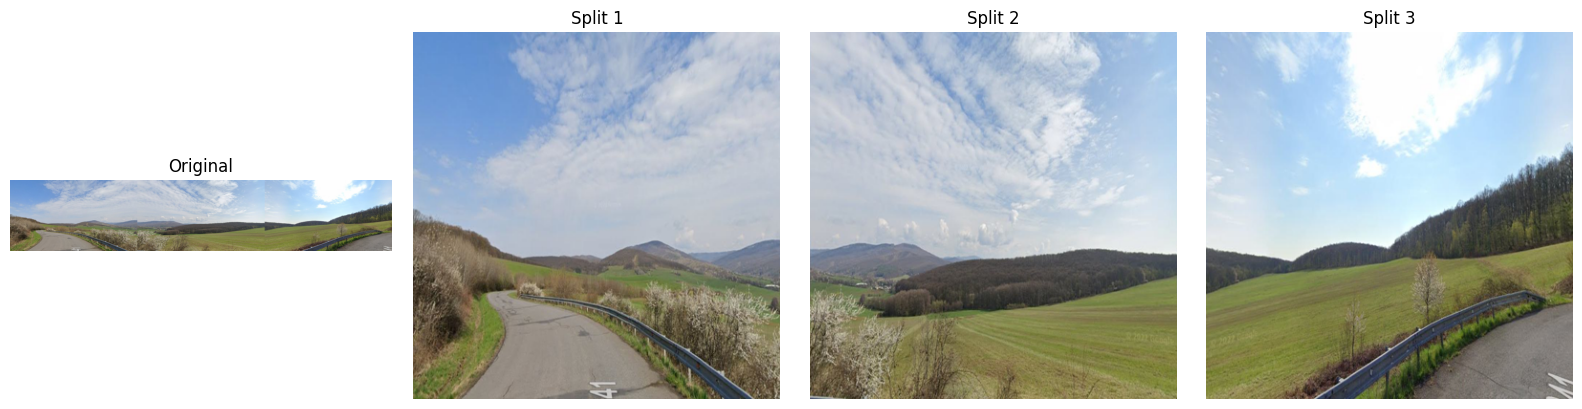

In [2]:

# Investigating splitting the data

from datasets import load_dataset
from PIL import Image
import matplotlib.pyplot as plt

# Step 1: Load the dataset
ds = load_dataset("stochastic/random_streetview_images_pano_v0.0.2")

# Step 2: Get the first image
first_image = ds["train"][0]['image']

# Step 3: Split and resize
def split_image_into_three(image: Image.Image, target_size=(384, 384)):
    width, height = image.size
    third_width = width // 3
    return [
        image.crop((i * third_width, 0, (i + 1) * third_width, height)).resize(target_size)
        for i in range(3)
    ]

resized_splits = split_image_into_three(first_image, target_size=(384, 384))



def show_split_example(dataset, index=0):
    original = dataset["train"][index]['image']
    splits = split_image_into_three(original)

    # Set up the figure
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(original)
    axes[0].set_title('Original')
    axes[0].axis('off')

    for i, split in enumerate(splits):
        axes[i+1].imshow(split)
        axes[i+1].set_title(f'Split {i+1}')
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()

# Call it to preview image 0
show_split_example(ds, index=1)




In [ ]:
from datasets import load_dataset, Dataset, DatasetDict, load_from_disk, concatenate_datasets
from glob import glob
from PIL import Image
import os
import torch
from torchvision import transforms

def handle_all_data(target_size, output_folder, final_output_path):



    # Load the dataset
    ds = load_dataset("stochastic/random_streetview_images_pano_v0.0.2")

    # Transform PIL → Tensor in [0,1]
    to_tensor = transforms.ToTensor()

    # Splitting function
    def split_image_into_three(image: Image.Image):
        width, height = image.size
        third_width = width // 3
        return [
            image.crop((i * third_width, 0, (i + 1) * third_width, height)).resize(target_size)
            for i in range(3)
        ]

    # Create output directory
    os.makedirs(output_folder, exist_ok=True)

    # Chunk processing + metadata preservation
    def process_and_save_split(split_data, split_name, chunk_size=300):
        for i in range(0, len(split_data), chunk_size):
            print(f"Processing {split_name} rows {i}–{min(i + chunk_size, len(split_data))}")
            batch = split_data.select(range(i, min(i + chunk_size, len(split_data))))
            output_rows = []
            for row in batch:
                try:
                    latitude = float(row['latitude'])
                    longitude = float(row['longitude'])
                    split_images = split_image_into_three(row['image'])
                    for img in split_images:
                        output_rows.append({
                            'image': to_tensor(img),
                            'country_iso_alpha2': row['country_iso_alpha2'],
                            'latitude': latitude,
                            'longitude': longitude,
                            'address': row['address'],
                        })
                except Exception as e:
                    print(f"Skipping row due to error: {e}")
            chunk_ds = Dataset.from_list(output_rows)
            chunk_ds.save_to_disk(f"{output_folder}/{split_name}_{i//chunk_size}")

    # Run the processing
    for split_name, split_data in ds.items():
        process_and_save_split(split_data, split_name)

    # Rebuild the full processed dataset
    all_splits = {}
    for split_name in ds.keys():
        chunks = sorted(glob(f"{output_folder}/{split_name}_*"))
        datasets = [load_from_disk(c) for c in chunks]
        all_splits[split_name] = concatenate_datasets(datasets)

    processed_dataset = DatasetDict(all_splits)

    # Shuffle and 80/20 split
    full_dataset = concatenate_datasets([d for d in processed_dataset.values()])
    full_dataset = full_dataset.shuffle(seed=42)
    split_dataset = full_dataset.train_test_split(test_size=0.2, seed=42)

    # Save final version
    split_dataset.save_to_disk(final_output_path)
    print(f"Finished! Saved to: {final_output_path}")


In [7]:

## For the square models
target_size = (384, 384)  # (width, height) for resized images

output_folder = "processed_chunks"
final_output_path = "processed_streetview"

handle_all_data(target_size, output_folder, final_output_path)

## For the rectangle model

target_size = (384, 256)  # (width, height) for resized images

output_folder = "processed_chunks_rect"
final_output_path = "processed_streetview_rect"

handle_all_data(target_size, output_folder, final_output_path)

NameError: name 'transforms' is not defined